In [3]:
import os
import requests
import pandas as pd
import json

# 1. Setup - Load your config
with open("retrieval_config.json", "r") as f:
    config = json.load(f)
API_KEY = config["API_KEY"]

# The Base URL (everything before the '?')
BASE_URL = "https://api.eia.gov/v2/electricity/state-electricity-profiles/capability/data/"

# 2. Define the parameters based on your dashboard URL
# We map the URL query strings into a Python dictionary
params = {
    'api_key': API_KEY,
    'frequency': 'annual',
    'data[0]': 'capability',
    'sort[0][column]': 'period',
    'sort[0][direction]': 'desc',
    'offset': 0,
    'length': 5000
}

def fetch_eia_data(url, parameters):
    try:
        print("Fetching data from EIA...")
        response = requests.get(url, params=parameters)
        
        # Raise exception if the request failed (e.g., 403 Forbidden, 404 Not Found)
        response.raise_for_status()
        
        # Parse JSON
        json_data = response.json()
        
        # The data resides in ['response']['data']
        data = json_data['response']['data']
        
        # Convert to DataFrame
        df = pd.DataFrame(data)
        
        # Check if we actually got data
        if df.empty:
            print("No data found for these parameters.")
            return None
            
        return df

    except requests.exceptions.HTTPError as e:
        print(f"HTTP Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return None

# 3. Execute and view results
df = fetch_eia_data(BASE_URL, params)

if df is not None:
    # Clean up: Convert capability to numeric (it often comes as strings)
    if 'capability' in df.columns:
        df['capability'] = pd.to_numeric(df['capability'], errors='coerce')
        
    print(f"Successfully retrieved {len(df)} rows.")
    print(df.head())
    
    # Save to CSV for backup
    # df.to_csv("eia_capability_data.csv", index=False)

Fetching data from EIA...
Successfully retrieved 5000 rows.
  period stateId stateDescription producertypeid producerTypeDescription  \
0   2024      AK           Alaska             EU      Electric Utilities   
1   2024      AK           Alaska             EU      Electric Utilities   
2   2024      AK           Alaska             EU      Electric Utilities   
3   2024      AK           Alaska             EU      Electric Utilities   
4   2024      AK           Alaska             EU      Electric Utilities   

  energysourceid energySourceDescription  capability capability-units  
0            ALL                     All      2638.9        megawatts  
1            BAT                 Battery       131.7        megawatts  
2            COL                    Coal        97.1        megawatts  
3            HYC           Hydroelectric       431.1        megawatts  
4             NG             Natural Gas      1236.6        megawatts  


In [4]:
df.head()

,period,stateId,stateDescription,producertypeid,producerTypeDescription,energysourceid,energySourceDescription,capability,capability-units
0,2024,AK,Alaska,EU,Electric Utilities,ALL,All,2638.9,megawatts
1,2024,AK,Alaska,EU,Electric Utilities,BAT,Battery,131.7,megawatts
2,2024,AK,Alaska,EU,Electric Utilities,COL,Coal,97.1,megawatts
3,2024,AK,Alaska,EU,Electric Utilities,HYC,Hydroelectric,431.1,megawatts
4,2024,AK,Alaska,EU,Electric Utilities,NG,Natural Gas,1236.6,megawatts


In [13]:
df[df['stateId'] == 'NC'].head()

,period,stateId,stateDescription,producertypeid,producerTypeDescription,energysourceid,energySourceDescription,capability,capability-units
1216,2024,NC,North Carolina,EU,Electric Utilities,ALL,All,26703.1,megawatts
1217,2024,NC,North Carolina,EU,Electric Utilities,BAT,Battery,127.8,megawatts
1218,2024,NC,North Carolina,EU,Electric Utilities,COL,Coal,5561.0,megawatts
1219,2024,NC,North Carolina,EU,Electric Utilities,HPS,Pumped Storage,86.0,megawatts
1220,2024,NC,North Carolina,EU,Electric Utilities,HYC,Hydroelectric,1795.7,megawatts


In [14]:
df_nc_generation = df.copy()
df_nc_generation['capability'] = pd.to_numeric(df_nc_generation['capability'], errors='coerce')

cols_to_drop = [
    'producertypeid', 
    'producerTypeDescription', 
    'energysourceid', 
    'energySourceDescription'
]
df_cleaned = df_nc_generation.drop(columns=cols_to_drop)
result = df_cleaned.groupby(['period', 'stateId'])['capability'].sum().reset_index()
result = result.rename(columns={'capability': 'total_capability'})

print(result)

    period stateId  total_capability
0     2022      AK           15310.4
1     2022      AL          145267.4
2     2022      AR           72772.4
3     2022      AZ          148095.0
4     2022      CA          454375.6
..     ...     ...               ...
105   2024      VT            4016.4
106   2024      WA          131253.8
107   2024      WI           89679.8
108   2024      WV           63192.0
109   2024      WY           47219.8

[110 rows x 3 columns]


In [15]:
result.head()

,period,stateId,total_capability
0,2022,AK,15310.4
1,2022,AL,145267.4
2,2022,AR,72772.4
3,2022,AZ,148095.0
4,2022,CA,454375.6


In [21]:
result[result['stateId'] == 'NC'].head()


,period,stateId,total_capability
33,2023,NC,190182.0
85,2024,NC,190406.2


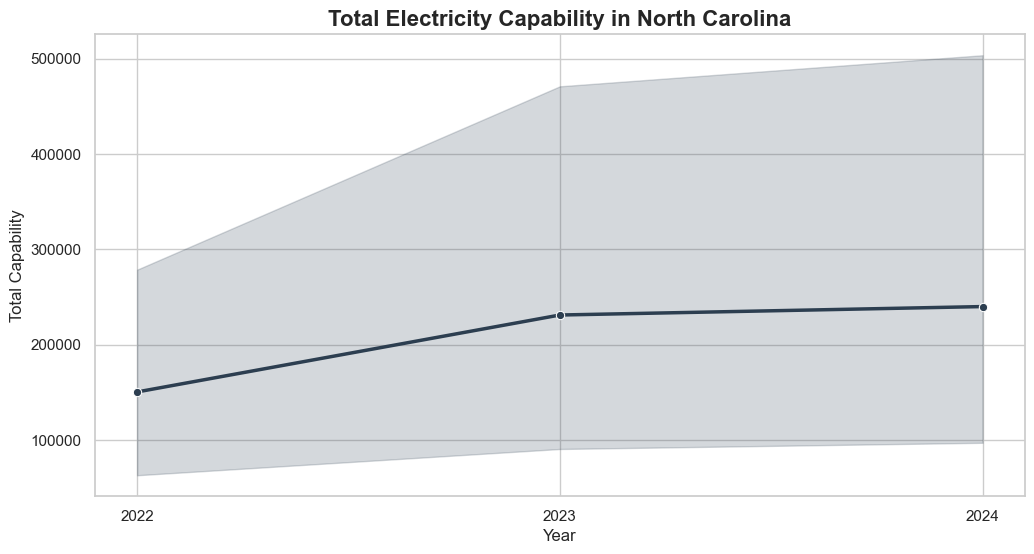

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

result = result.sort_values('period')

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=result, 
    x='period', 
    y='total_capability', 
    marker='o', 
    linewidth=2.5, 
    color='#2c3e50'
)

plt.title('Total Electricity Capability in North Carolina', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Capability', fontsize=12)

plt.xticks(result['period'].unique())

# Show the plot
plt.show()

In [3]:
import os
import requests
import pandas as pd
import json
import time

# 1. Load Configuration
with open("retrieval_config.json", "r") as f:
    config = json.load(f)
API_KEY = config["API_KEY"]

def fetch_all_eia_data(base_url, params):
    all_data = []
    offset = 0
    length = params.get('length', 5000)
    params['api_key'] = API_KEY

    while True:
        params['offset'] = offset
        try:
            # I'm printing the URL so you can see exactly what is being sent
            # You can paste this URL into a browser to test it!
            response = requests.get(base_url, params=params)
            
            if response.status_code == 400:
                print(f"Error 400: {response.text}")
                return pd.DataFrame()
                
            response.raise_for_status()
            json_data = response.json()
            data = json_data['response']['data']
            total_available = int(json_data['response']['total']) 
            
            if not data:
                break
                
            all_data.extend(data)
            if len(all_data) >= total_available:
                break
            offset += length
            time.sleep(0.2) 
        except Exception as e:
            print(f"Error: {e}")
            break
    return pd.DataFrame(all_data)

# ======================================================================
# DATASET 2: Electric Power Operational Data (NC FILTERED)
# ======================================================================

URL_OPERATIONAL = "https://api.eia.gov/v2/electricity/electric-power-operational-data/data/"

params_operational = {
    'frequency': 'monthly',
    'data[0]': 'generation',
    'sort[0][column]': 'period',
    'sort[0][direction]': 'desc',
    'offset': 0,
    'length': 5000,
    
    # --- THE CRITICAL FIX ---
    # The column is called 'location', but the FILTER is called 'state'
    'filter[0][facet]': 'state', 
    'filter[0][values]': 'NC'
}

# Execute
df_nc_generation = fetch_all_eia_data(URL_OPERATIONAL, params_operational)

if not df_nc_generation.empty:
    # Clean up
    df_nc_generation['generation'] = pd.to_numeric(df_nc_generation['generation'], errors='coerce')
    
    # Only keep the columns you want
    desired_cols = ['period', 'location', 'stateDescription', 'generation', 'generation-units']
    existing_cols = [c for c in desired_cols if c in df_nc_generation.columns]
    df_nc_generation = df_nc_generation[existing_cols]
    
    print(f"\nSuccess! Retrieved {len(df_nc_generation)} rows for North Carolina.")
    print(df_nc_generation.head())
else:
    print("\nStill getting a 400 error. Please check if the API Key is valid.")

Error 400: {"error":"Invalid parameter 'filter' provided. The only valid parameters are 'frequency', 'data', 'facets', 'start', 'end', 'sort', 'offset', 'length', and 'api_key'.","code":400}

Still getting a 400 error. Please check if the API Key is valid.


In [8]:
df_generation.head()

,period,location,stateDescription,sectorid,sectorDescription,fueltypeid,fuelTypeDescription,generation,generation-units
0,2026-01,90,Pacific,1,Electric Utility,ALL,all fuels,22889.99184,thousand megawatthours
1,2026-01,90,Pacific,1,Electric Utility,AOR,all renewables,558.39892,thousand megawatthours
2,2026-01,90,Pacific,1,Electric Utility,BIO,biomass,37.05399,thousand megawatthours
3,2026-01,90,Pacific,1,Electric Utility,COL,"coal, excluding waste coal",46.34671,thousand megawatthours
4,2026-01,90,Pacific,1,Electric Utility,COW,all coal products,46.34671,thousand megawatthours


In [7]:
df_generation['stateDescription'].unique()

<StringArray>
[             'Pacific',               'Alaska',              'Alabama',
             'Arkansas',              'Arizona',           'California',
             'Colorado',          'Connecticut', 'District of Columbia',
             'Delaware',   'East North Central',   'East South Central',
              'Florida',              'Georgia',               'Hawaii',
                 'Iowa',                'Idaho',             'Illinois',
              'Indiana']
Length: 19, dtype: str

In [27]:
# 1. Convert generation to numeric
df_generation['generation'] = pd.to_numeric(df_generation['generation'], errors='coerce')

# 2. Group by state AND period
state_period_totals = df_generation.groupby(['stateDescription', 'period'])['generation'].sum().reset_index()

# Rename column for clarity
state_period_totals = state_period_totals.rename(columns={'generation': 'total_generation'})

state_period_totals.head(10)

,stateDescription,period,total_generation
0,Alabama,2026-01,1.961067e+05
1,Alaska,2026-01,9.813939e+03
2,Arizona,2026-01,1.455500e+05
3,Arkansas,2026-01,9.503883e+04
4,California,2026-01,2.811978e+05
5,Colorado,2026-01,9.623481e+04
6,Connecticut,2026-01,6.837442e+04
7,Delaware,2026-01,8.796515e+03
8,District of Columbia,2026-01,3.727370e+02
9,East North Central,2026-01,1.151322e+06


In [31]:
print(f"Dataset starts at: {df_generation['period'].min()}")
print(f"Dataset ends at: {df_generation['period'].max()}")

Dataset starts at: 2026-01
Dataset ends at: 2026-01
